# Anomaly detection with a frozen AstroPT backbone

Loads the same released [`Smith42/astroPT`](https://huggingface.co/Smith42/astroPT)
checkpoint as `astropt_finetuning.ipynb`, but uses it purely as a
frozen feature extractor (no finetuning) on
[`Smith42/galaxies`](https://huggingface.co/datasets/Smith42/galaxies) —
the reference authors' own probing dataset, streamed (first 2,000 examples
with a measured `merging_merger_fraction`; see `utils/galaxies.py`), rather
than reusing GZ10 a fourth time. Computes one embedding per galaxy, then
scores every embedding with Local Outlier Factor (cosine metric) and
inspects the highest-scoring outliers, following the reference model's
`scripts/euclid/downstream_tasks/anomaly_detection.py` — specifically the
method its own script settles on (`methods = ['LOF']`).

That reference script keys everything to a Euclid FITS/catalog pipeline
(datacubes, object-property tables); here the anomalous galaxies are shown
directly from their images, and the reference's own cross-check property,
`merging_merger` — a debiased Galaxy Zoo vote fraction, available on
`Smith42/galaxies` as `merging_merger_fraction` — is used directly instead
of a GZ10 label stand-in. The 2D layout uses `sklearn.manifold.TSNE` in
place of UMAP, matching `gcnn_analysis.ipynb`'s reasoning for reusing
the already-installed `scikit-learn` dependency.

## Install example-only dependencies

Not part of AstroLens' core install (`requirements.txt`) — only needed for this example.

In [7]:
!pip install -q datasets torchvision scikit-learn huggingface_hub matplotlib

## Imports

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.manifold import TSNE
from sklearn.neighbors import LocalOutlierFactor
from torch.utils.data import DataLoader
from torchvision import transforms

from utils import galaxies
from utils.astropt import compute_embeddings, load_pretrained_astropt

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load the dataset, backbone, and embeddings

Streams `N_EXAMPLES` from `Smith42/galaxies` (`utils/galaxies.py`) —
embedding-based analysis only needs inference, no training data. The model
has no task head and no LoRA adapters (`load_pretrained_astropt` defaults
to `num_classes=0`, `lora_r=0`): the whole backbone stays frozen and is
used only through `forward_features`, mean-pooled into one embedding per
galaxy by `compute_embeddings` (see `astropt_finetuning.ipynb` for
what `load_pretrained_astropt` transfers from the checkpoint and why).

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 64
N_EXAMPLES = 2000 # reduce this if compute embeddings takes too long 
PROPERTY_KEY = "merging_merger_fraction"

examples = galaxies.load_galaxies(N_EXAMPLES, columns=["image", PROPERTY_KEY], filter_key=PROPERTY_KEY)
properties = np.array([example[PROPERTY_KEY] for example in examples])

# no pixel Normalize here: AstroPT.patchify normalizes each patch to zero
# mean/unit variance itself, matching the reference model's pretraining input
eval_transform = transforms.Compose(
    [
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
    ]
)

dataset = galaxies.GalaxiesDataset(examples, eval_transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, num_workers=4)

model = load_pretrained_astropt(IMG_SIZE, device)
embeddings = compute_embeddings(model, loader, device)

embeddings.shape

Resolving data files:   0%|          | 0/1533 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1533 [00:00<?, ?it/s]

streaming galaxies:   0%|          | 0/2000 [00:00<?, ?ex/s]

embedding:   0%|          | 0/32 [00:00<?, ?batch/s]

(2000, 768)

## Anomaly detection

Scores every embedding with `sklearn.neighbors.LocalOutlierFactor` (cosine
metric), following `anomaly_detection.py`'s `run_anomaly_detection('lof', ...)`
(`contamination=0.01`, sign-inverted so higher = more anomalous), then shows
the galaxies with the highest scores against a `sklearn.manifold.TSNE`
projection of the embeddings for context.

Text(0.5, 0.98, 'Top anomalies by Local Outlier Factor')

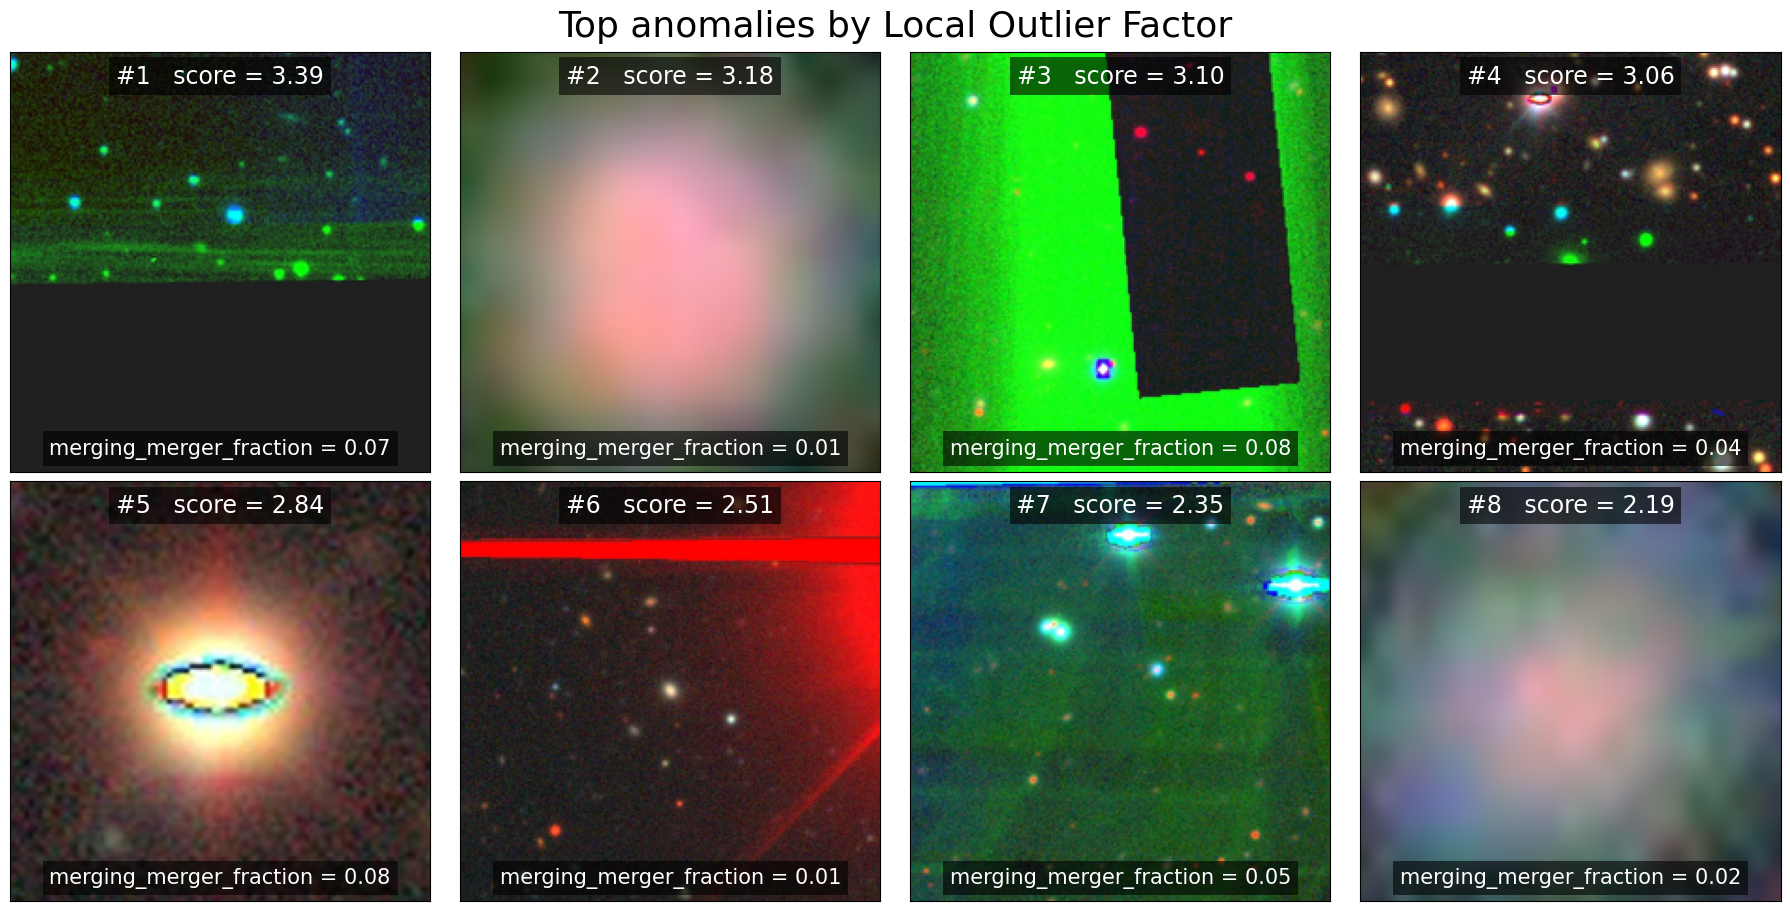

In [10]:
TOP_N = 8
N_COLS = 4
lof = LocalOutlierFactor(n_neighbors=20, metric="cosine", contamination=0.01)
lof.fit_predict(embeddings)
anomaly_scores = -lof.negative_outlier_factor_  # higher = more anomalous

top_anomalies = np.argsort(anomaly_scores)[::-1][:TOP_N]

n_rows = int(np.ceil(TOP_N / N_COLS))
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(4.5 * N_COLS, 4.5 * n_rows), layout="constrained")
for rank, (ax, idx) in enumerate(zip(axes.flat, top_anomalies), start=1):
    image = dataset[idx]
    ax.imshow(image.permute(1, 2, 0).numpy())
    ax.text(
        0.5,
        0.97,
        f"#{rank}   score = {anomaly_scores[idx]:.2f}",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=17,
        color="white",
        bbox=dict(facecolor="black", alpha=0.6, edgecolor="none", pad=5),
    )
    ax.text(
        0.5,
        0.03,
        f"{PROPERTY_KEY} = {properties[idx]:.2f}",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=15,
        color="white",
        bbox=dict(facecolor="black", alpha=0.6, edgecolor="none", pad=5),
    )
    ax.set_xticks([])
    ax.set_yticks([])
for ax in axes.flat[TOP_N:]:
    ax.axis("off")
fig.suptitle("Top anomalies by Local Outlier Factor", fontsize=26)


[]

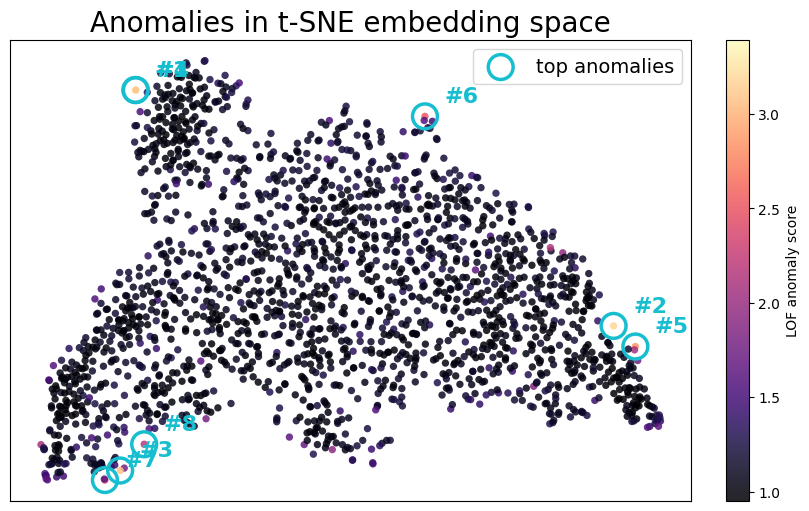

In [14]:
projection = TSNE(n_components=2, random_state=0, init="pca").fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
points = ax.scatter(
    *projection.T, c=anomaly_scores, cmap="magma", s=28, alpha=0.85, linewidths=0
)
ax.scatter(
    *projection[top_anomalies].T,
    s=320,
    facecolors="none",
    edgecolors="tab:cyan",
    linewidths=2.5,
    label="top anomalies",
)
for rank, idx in enumerate(top_anomalies, start=1):
    ax.annotate(
        f"#{rank}",
        projection[idx],
        textcoords="offset points",
        xytext=(14, 10),
        fontsize=16,
        color="tab:cyan",
        fontweight="bold",
    )
fig.colorbar(points, ax=ax, label="LOF anomaly score")
ax.legend(fontsize=14, loc="best")
ax.set_title("Anomalies in t-SNE embedding space", fontsize=20)
ax.set_xticks([])
ax.set_yticks([])


Following the reference script's own merger-histogram check
(`scripts/euclid/downstream_tasks/similarity_search.py`): compare
`merging_merger_fraction` among the anomalies to its distribution over the
whole sample.

merging_merger_fraction among anomalies: mean=0.047
merging_merger_fraction over the whole sample: mean=0.068


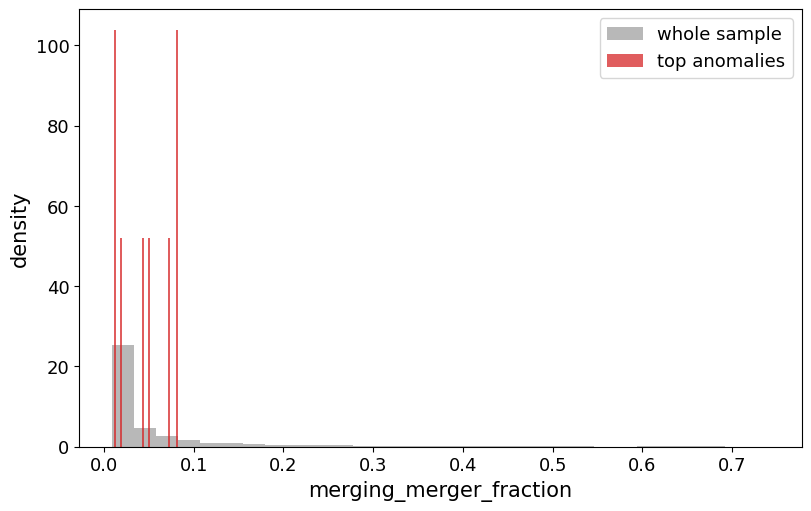

In [12]:
print(f"{PROPERTY_KEY} among anomalies: mean={properties[top_anomalies].mean():.3f}")
print(f"{PROPERTY_KEY} over the whole sample: mean={properties.mean():.3f}")

fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
ax.hist(properties, bins=30, density=True, alpha=0.55, color="tab:gray", label="whole sample")
ax.hist(properties[top_anomalies], bins=30, density=True, alpha=0.75, color="tab:red", label="top anomalies")
ax.set_xlabel(PROPERTY_KEY, fontsize=15)
ax.set_ylabel("density", fontsize=15)
ax.tick_params(labelsize=13)
ax.legend(fontsize=13)
